<a href="https://colab.research.google.com/github/srkatsaras/FRTN65---Code-and-Notebooks/blob/main/lab_song_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [13]:
# Import modules
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier

In [3]:
# Download data
!wget -O training_data.csv http://handsonml.control.lth.se/data/training_data.csv
!wget -O songs_to_classify.csv http://handsonml.control.lth.se/data/songs_to_classify.csv

--2026-09-24 00:06:55--  http://handsonml.control.lth.se/data/training_data.csv
Resolving handsonml.control.lth.se (handsonml.control.lth.se)... 130.235.83.36, 2001:6b0:16:248:2406:1311:4200:0
Connecting to handsonml.control.lth.se (handsonml.control.lth.se)|130.235.83.36|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 54950 (54K) [text/csv]
Saving to: ‘training_data.csv’

training_data.csv   100%[===================>]  53.66K   222KB/s    in 0.2s    

2026-09-24 00:06:55 (222 KB/s) - ‘training_data.csv’ saved [54950/54950]

--2026-09-24 00:06:55--  http://handsonml.control.lth.se/data/songs_to_classify.csv
Resolving handsonml.control.lth.se (handsonml.control.lth.se)... 130.235.83.36, 2001:6b0:16:248:2406:1311:4200:0
Connecting to handsonml.control.lth.se (handsonml.control.lth.se)|130.235.83.36|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 14306 (14K) [text/csv]
Saving to: ‘songs_to_classify.csv’

songs_to_classify.c 100%[==========

In [4]:
# Load data
train = pd.read_csv("training_data.csv")
test = pd.read_csv("songs_to_classify.csv")
train.shape, test.shape

((750, 14), (200, 13))

In [5]:
# Inspect data
train.sample(5)

,acousticness,danceability,duration,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,time_signature,valence,label
184,0.37000,0.916,196000,0.804,0.000012,0,0.0812,-3.406,1,0.0490,120.028,4,0.538,0
211,0.05130,0.459,215987,0.757,0.011700,8,0.1160,-7.573,0,0.0538,176.978,4,0.290,1
741,0.16200,0.710,309173,0.784,0.000623,0,0.1940,-6.865,1,0.0416,126.656,4,0.901,1
484,0.84200,0.640,254491,0.352,0.000002,11,0.2460,-7.555,0,0.0273,107.769,4,0.588,1
420,0.00146,0.908,393333,0.928,0.853000,1,0.0532,-5.972,1,0.1730,128.024,4,0.207,0


AttributeError: Line2D.set() got an unexpected keyword argument 'x_bins'

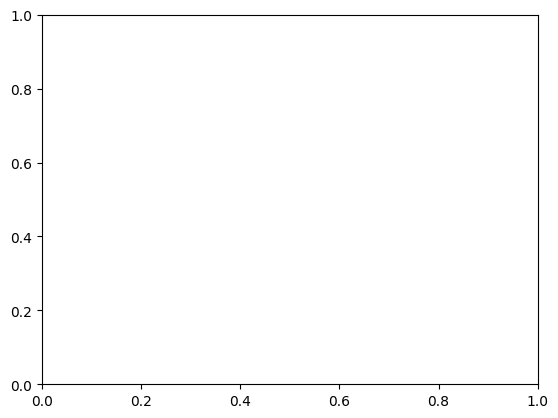

In [21]:
dataset['AcousticnessBin'] = pd.cut(dataset['acousticness'].astype(int), 5)

sns.lineplot(x = 'acousticness', y = 'label',  data=train, x_bins=10)

In [8]:
# select which features to use
features = ['danceability','key','loudness','instrumentalness','liveness']
X_train = train.loc[:,features]
y_train = train.loc[:,'label']
X_test = test.loc[:,features]


In [9]:
X_train

,danceability,key,loudness,instrumentalness,liveness
0,0.514,8,-14.835,0.816000,0.1120
1,0.714,4,-6.935,0.000000,0.2630
2,0.630,5,-9.290,0.000004,0.1270
3,0.810,5,-11.005,0.210000,0.1840
4,0.465,6,-8.137,0.000173,0.0692
...,...,...,...,...,...
745,0.374,6,-4.108,0.000156,0.1250
746,0.487,10,-3.293,0.006020,0.0968
747,0.605,0,-7.631,0.000000,0.3590
748,0.700,3,-6.892,0.000028,0.1220


In [10]:
# Normalize data. Can also be done using sklearn methods such as
# MinMaxScaler() or StandardScaler()
X_trainn = X_train*1/np.max(np.abs(X_train), axis=0)
X_testn = X_test*1/np.max(np.abs(X_train), axis=0)

In [11]:
# note: all inputs/features are treated as quantitative/numeric
# some of the features are perhaps more sensible to treat as
# qualitative/cathegorical. For that sklearn preprocessing methods
# such as OneHotEncoder() can be used

# define the k-NN model. To set n_neighbors in a systematic way, use cross validation!
knnmodel = KNeighborsClassifier(n_neighbors=5)

# feed it with data and train it
knnmodel.fit(X_trainn, y_train)

# make predictions
predictions = knnmodel.predict(X=X_testn)
print(predictions)

[0 1 0 1 0 0 0 1 0 0 1 0 0 1 1 1 1 0 1 1 0 0 1 0 0 1 1 0 0 1 1 1 1 1 0 1 1
 1 0 1 0 1 0 1 1 1 0 1 1 0 1 0 1 0 0 1 1 1 0 0 1 1 0 0 1 1 1 0 1 1 1 0 1 1
 1 1 0 1 1 0 1 1 0 0 1 0 1 1 1 1 1 0 0 0 1 0 1 1 1 1 0 0 1 0 0 1 0 0 0 1 1
 1 0 1 1 0 0 1 0 0 0 1 1 0 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 0 1 0 0 1 1 1 0 0
 1 0 1 1 1 0 1 1 1 1 1 1 0 1 0 1 1 1 1 1 1 1 1 1 1 0 1 0 1 1 1 0 1 1 1 1 1
 1 1 0 0 0 1 0 0 0 1 1 1 1 1 1]
